# **Analisis variables - Géneros**

# Bibliotecas

In [3]:
#Carga de datos
import pandas as pd
import json
import numpy as np
from Server_PD import download_dataframe_minio

from collections import Counter
import re

#Graficas
import seaborn as sns
import matplotlib.pyplot as plt
import isodate

from itertools import combinations
from collections import Counter
import ast

import analisisutils as utils


Es importante destacar que este notebook utiliza una versión preliminar del dataset. La funcion utilizada en el notebook "analisis_kids" no estaba definida cuando analizamos los datos. Al intentar ultilizar la nueva función los datos cambian demasiado, por eso hemos decidido conservar la versión inicial. Implementaremos la función de carga de datos definitiva en la próxima fase.

# Carga de datos

In [ ]:
#Accedemos al dataframe más reciente de datos
with open("Private/Claves.json", "r", encoding="utf-8") as archivo:
    claves = json.load(archivo)

claves["Url"] = claves["Url"].replace("https://", "").replace("http://", "").split("/")[0]
df = download_dataframe_minio("pd1", "grupo1/clean/union_dfs_20260304",claves=claves,file_format="parquet")
df.tail()

,ID,Titulo,Descripcion,Visualizaciones,Tags,Duracion,Fecha_publicacion,Titulo_canal,Subtitulos,Generos,Subgeneros,Made for kids,Rango_edad
7496,ZgPNls6XkD0,REAL NIGHTLIFE in Ho Chi Minh City Vietnam!,#shorts REAL NIGHTLIFE in Ho Chi Minh City Vie...,41,"nightlife, ho chi minh, saigon, ho chi minh ni...",PT52S,2026-03-03 12:30:46+00:00,Life and Living HP,None,Travel & Events,"Electronic music, Lifestyle (sociology)",False,Adult
7497,9JIYbiKRWQs,Preparing a hedge for laying at Hill Park,At the end of February we joined staff and vol...,18,yt:stretch=4:3,PT2M20S,2026-03-03 09:27:14+00:00,Surrey Wildlife Trust,"Kind: captions Language: en Hi, I'm Stuart. I'...",Nonprofits & Activism,Lifestyle (sociology),False,Adult
7498,_jmR25N2Qso,Two 19-year-old suspects wanted for fatal GTA ...,Police have issued arrest warrants for two 19-...,8510,"CTV, News, CTV News, CTV National News, Canadi...",PT45M58S,2026-03-03 22:35:34+00:00,CTV News,Kind: captions Language: en Good afternoon. To...,News & Politics,Society,False,Adult
7499,FqzoXp7oQOA,State lawmakers continue to discuss NYSERDA memo,New Yorkers from around the state still had qu...,18,video,PT2M29S,2026-03-03 21:59:57+00:00,WTEN,Kind: captions Language: en There are still qu...,News & Politics,"Politics, Society, Television program",False,Adult
7500,uEdPZ7SCas8,Classic Street Rhythms — Fusion Jazz Funk Groo...,Classic Street Rhythms — Fusion Jazz Funk Groo...,32,"jazz funk, jazz music, funk jazz, funky jazz, ...",PT3H32M19S,2026-03-04 01:30:00+00:00,Funky Blue Note,None,Music,"Jazz, Music",False,Adult


# Transformamos la columna "Duracion"

In [7]:
df['Duracion'] = df['Duracion'].apply(utils.iso_a_minutos)

# Limpiamos los datos

- Igualamos el formato. 
- Quitamos caracteres extraños. 
- Separamos los generos que están juntos para tratarlos individualmente. 
- Eliminamos nulos y duplicados.

In [9]:
"""
Limpieza de datos
"""

df['Generos'] = df['Generos'].apply(utils.limpieza_final)

#Filtramos los videos que no tienen genero asignado
df = df[df['Generos'].apply(len) > 0].copy()



# Top 20 géneros mas frecuentes

C:\Users\javil\AppData\Local\Temp\ipykernel_12428\3089516639.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')


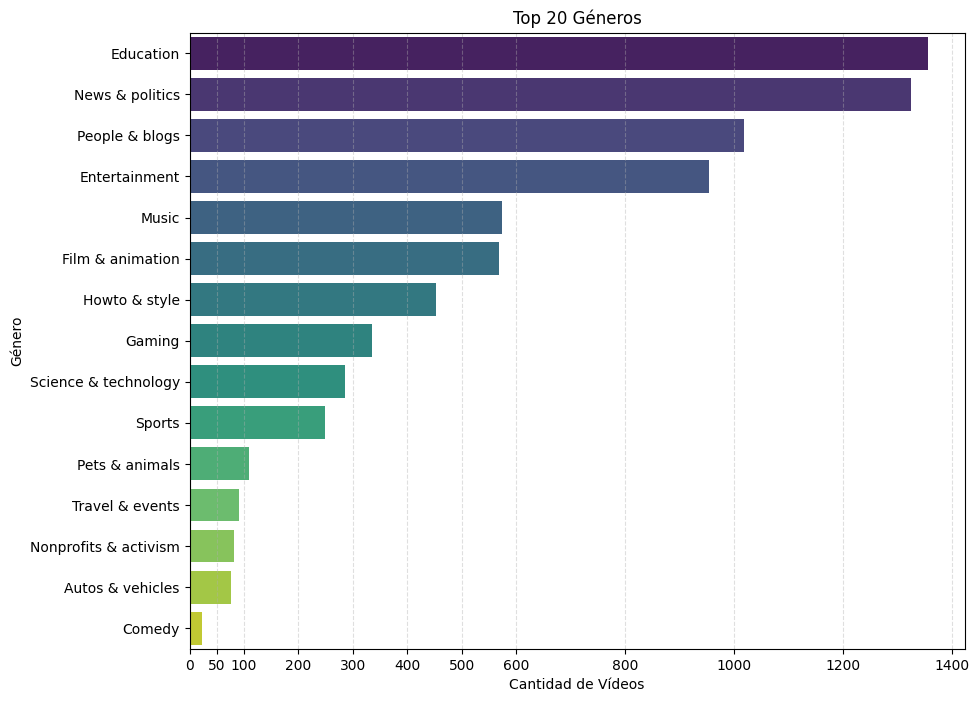

In [10]:
"""
Grafica que muestra los top 20 generos mas frecuentes
"""
top_20 = df['Generos'].explode().value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20.values, y=top_20.index, palette='viridis')

# Ticks
max_frecuencia = top_20.max()

tus_ticks = [0, 50, 100, 300, 500]

paso_automatico = 200 if max_frecuencia < 2000 else 500
ticks_automaticos = list(range(0, int(max_frecuencia) + paso_automatico, paso_automatico))

ticks_finales = sorted(list(set(tus_ticks + ticks_automaticos)))

plt.xticks(ticks_finales)

#Detalles
plt.title("Top 20 Géneros")
plt.xlabel("Cantidad de Vídeos")
plt.ylabel("Género")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

La gráfica muestra un dominio de dos categorías que superan los 2000 vídeos.
'Society' y 'Lifestyle'. Esto indica que la mayor parte del contenido de nuestra base de datos se basa en personas, opinión o hechos sociales.

Observamos también categorías muy cercanas
Podemos apreciar como los géneros más comunes son muy generales. Pueden abarcar muchos temas distintos. A medida que vamos bajando en el número de videos, vemos como son temas más específicos que se podrían tratar como subcategorías. Por ejemplo. 'Role-playing video game' podría estar dentro de la categoría de videojuegos.
Además hay categorías que se podrían considerar cercanas como 'Television program' y 'Film', o 'Society' y 'Politics'. Muchos vídeos podrían pertenecer a ambos, por ello utilizaremos listas de géneros además de una etiqueta única y general (clasificación multietiqueta).

De esta forma podremos usar esta información para definir cuáles serán los géneros que asignaremos como principales (los estén al principio de la gráfica) y cuales tomaremos como subcategorías (los menos frecuentes).


# Gráfico de correlacion 

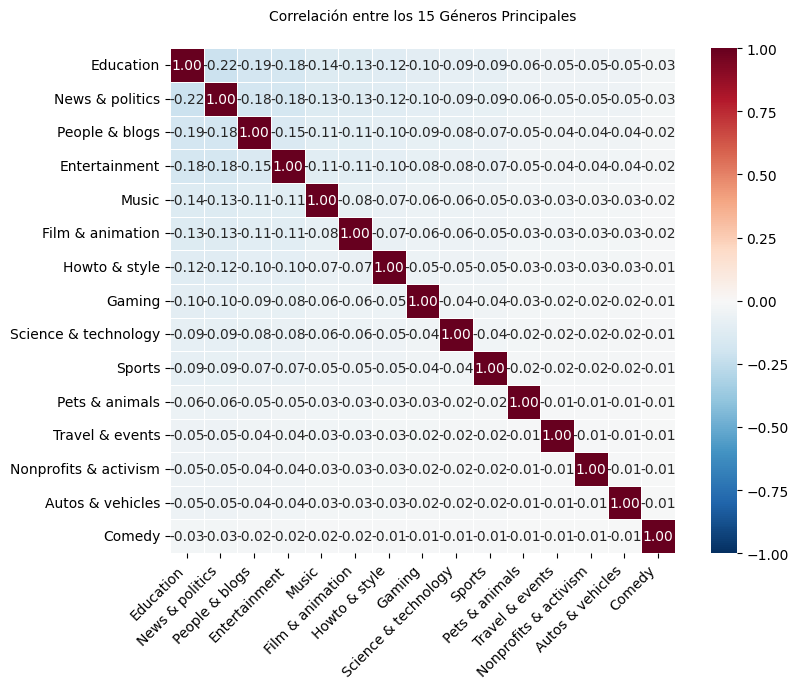

In [12]:

# Convertimos la lista de géneros en columnas (One-Hot Encoding)
# Tabla que me dice 1 si el video tiene el genero, 0 si no
df_dummies = df['Generos'].explode().str.get_dummies().groupby(level=0).sum()

# Usamos el top 15 para que sea legible
top_15_nombres = df['Generos'].explode().value_counts().head(15).index
df_top = df_dummies[top_15_nombres]

# Matriz correlacion
matriz_corr = df_top.corr()

# Configuración del Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    matriz_corr, 
    annot=True,
    fmt='.2f',            
    cmap="RdBu_r",        
    center=0,             
    vmin=-1, vmax=1,      
    linewidths=.5,        
    square=True          
)

plt.title("Correlación entre los 15 Géneros Principales", fontsize=10, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Lo primero que vemos al observar el clustermap es que hay una fuerte correlación entre 'Film' 'Entertainment' y entre 'Society' y 'Politics'. Esto indica que casi todos los vídeos de política se etiquetan también como sociedad y los de cine como entretenimiento. Por ejemplo, si el modelo predice "Politics", es casi seguro que acertará "Society". Esto facilita la clasificación pero también indica que las fronteras entre estos géneros son difusas.

Nos encontramos también con categorías solitarias. Por ejemplo, 'Religión'. Estas serán las más fáciles de aislar y clasificar correctamente, ya que no comparten rasgos con el resto.

Podemos observar otros casos donde hay correlación entre categorías donde existe una relación de jerarquía. Este es el caso de 'Music' y 'Pop music'. 'Pop music' es una subcategoría de 'Music'.

Hay géneros que rara vez aparecen juntos. Es poco probable ver un vídeo que sea simultáneamente 'Video game culture' y 'Politics'. Podemos usar esto como una regla de descarte. Si detecta keywords de videojuegos, puede bajar drásticamente la probabilidad de que el vídeo sea de política.


In [13]:
#Creamos un diccionario con df's de filtrando 6 generos mas frecuentes
top_6 = df['Generos'].explode().value_counts().head(6).index.tolist()
dfs_generos = {}
nombres = []
for genero in top_6 :
    nombre_df = f"{genero.lower().replace(' ', '_')}"
    nombres.append(nombre_df)
    dfs_generos[nombre_df] = df[df['Generos'].apply(lambda x: genero in x)].copy()

print("Los df's con los que vamos a trabajar son:")
for nombre in nombres:
    print(nombre)


Los df's con los que vamos a trabajar son:
education
news_&_politics
people_&_blogs
entertainment
music
film_&_animation


# Keywords


**TÍTULO**

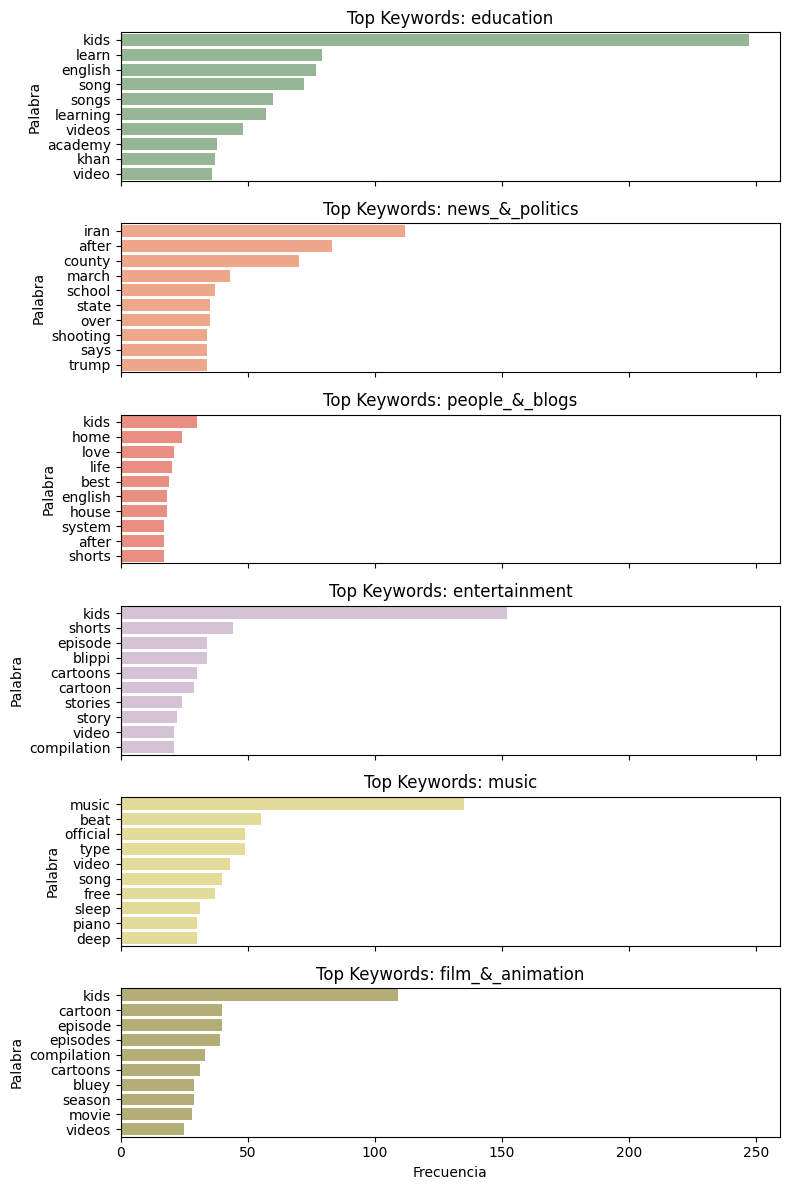

In [14]:
#Palabras más comunes en títulos
fig, ax = plt.subplots(6, 1, figsize=(8, 12), sharex=True)

colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki']

for i, nombre, color in zip(range(0, 6), nombres, colores):
    utils.graficar_palabras_comunes(dfs_generos[nombre], 'Titulo', f'Top Keywords: {nombre}', ax[i], color)    

plt.tight_layout()
plt.show()


Generos como 'Music' y 'Society' presentan palabras clave muy descriptivas. Por ejemplo en 'Music' encontramos palabras como 'song', 'beat', 'official', 'jazz' que definen el contenido del video de manera muy descriptiva. En Society, palabras como 'Police', 'Trump' o 'News' actúan como indicadores claros. 
Para el modelo, estas categorías serán más fáciles de clasificar mediante técnicas de procesamiento de lenguaje natural.

Encontramos un solapamiento entre 'Film' y 'Entertainment'
Ambos géneros comparten términos más genéricos como 'songs', 'cartoons', 'episode', 'love' o 'kids'.
Esto confirma lo que aparece en el Heatmap, son categorías más difusas. El modelo necesitará algo más que palabras sueltas para distinguir entre un vídeo de entretenimiento y uno de cine.

Se aprecia la existencia de nombres propios (por ejemplo, 'Trump') o eventos globales dominan ciertos géneros. Esto puede suponer un riesgo ya que si entrenamos el modelo hoy, aprenderá que la política es igual a 'Trump'. Esto es un sesgo temporal. 


**SUBTÍTULOS**

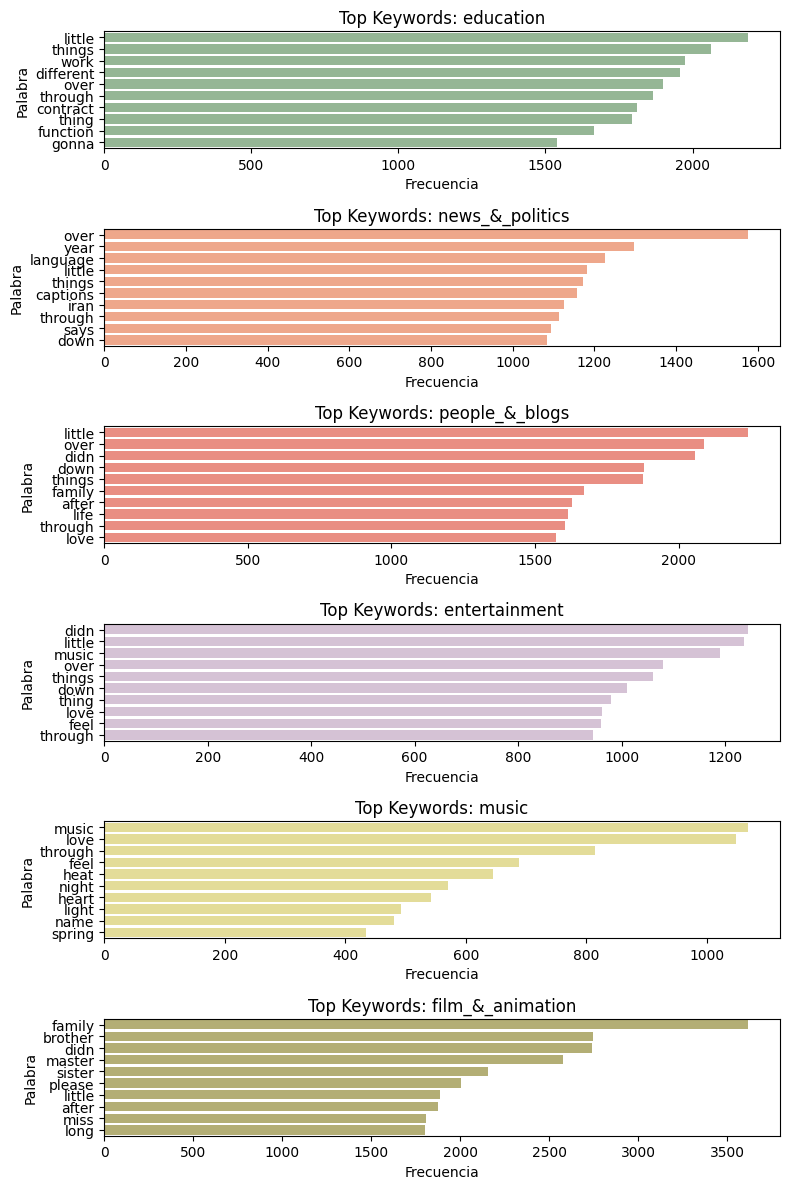

In [15]:
#Palabras más comunes en subtítulos
fig, ax = plt.subplots(6, 1, figsize=(8, 12))

colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki']

for i, nombre, color in zip(range(0, 6), nombres, colores):
    utils.graficar_palabras_comunes(dfs_generos[nombre], 'Subtitulos', f'Top Keywords: {nombre}', ax[i], color)    

plt.tight_layout()
plt.show()

# Densidad de habla

In [16]:
for nombre in nombres:
    dfs_generos[nombre]['Palabras_Por_Minuto'] = dfs_generos[nombre].apply(utils.calcular_wpm, axis=1)
    dfs_generos[nombre]['Palabras_Por_Minuto'] = round(dfs_generos[nombre]['Palabras_Por_Minuto'], 2)

C:\Users\javil\AppData\Local\Temp\ipykernel_12428\3966051181.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_comparativa_generos, palette='Set2')


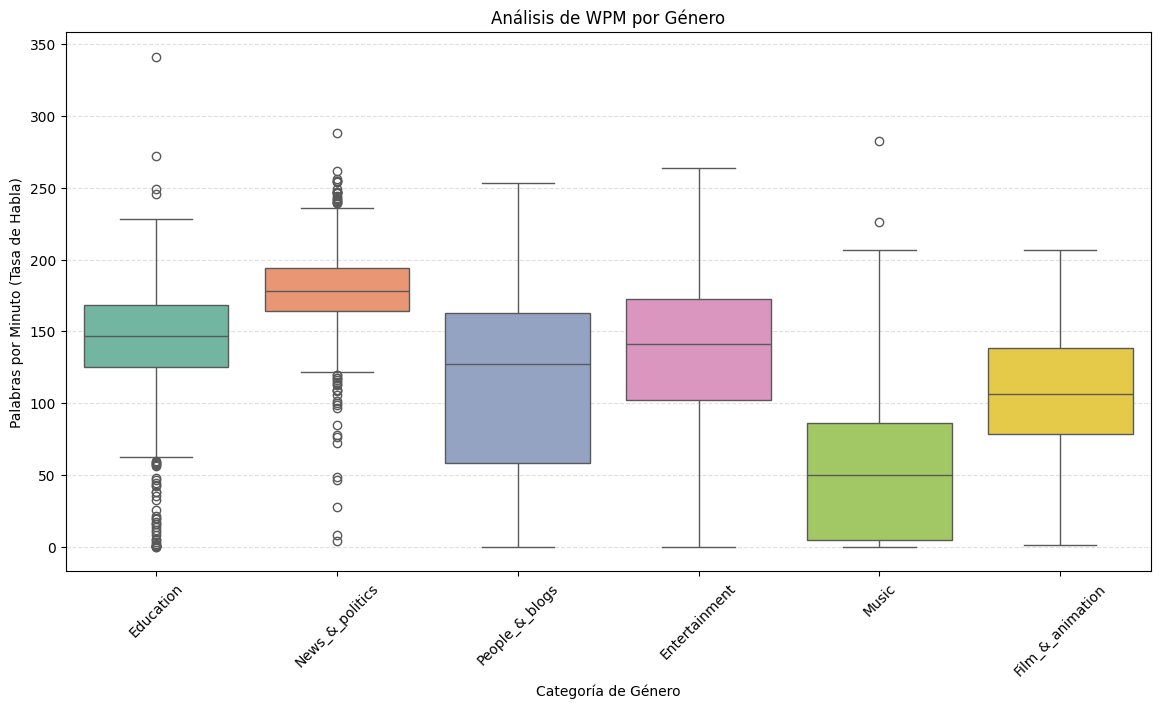

In [17]:
# Filtramos los vídeos que no tienen subtitulos
df_comparativa_generos = pd.concat([
    dfs_generos[nombre][dfs_generos[nombre]['Subtitulos'].astype(str).str.lower().isin(['none', 'nan']) == False].assign(
        Genero=nombre.replace('df_', '').capitalize()
    ) 
    for nombre in nombres
])

plt.figure(figsize=(14, 7))

sns.boxplot(x='Genero', y='Palabras_Por_Minuto', data=df_comparativa_generos, palette='Set2')

plt.title('Análisis de WPM por Género')
plt.xlabel('Categoría de Género')
plt.ylabel('Palabras por Minuto (Tasa de Habla)')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [18]:
print("Valores máximos de WPM detectados por género:")
print(df_comparativa_generos.groupby('Genero')['Palabras_Por_Minuto'].max().sort_values(ascending=False))

Valores máximos de WPM detectados por género:
Genero
Education           341.31
News_&_politics     288.52
Music               282.66
Entertainment       263.57
People_&_blogs      253.56
Film_&_animation    206.90
Name: Palabras_Por_Minuto, dtype: float64


'Society' y 'Knowledge' son los géneros con mayor densidad verbal y consistencia, presentando una mediana elevada y un rango intercuartílico estrecho en comparación con los demás. Esto puede estar justificado por que los videos son mas cortos de lo usual. Ambos presentan outliers. Esto puede deberse a que son vídeos con una carga informativa y narrativa superior.

'Music' y 'lifestyle' presentan las medianas de WPM más bajas. Esto puede ser un inficador de predominancia de contenido visual sobre el verbal.

'Entertainment' y 'Film' son bastante similares. Esto se puede que tenga relacion con el hecho de que son categorías que están notablemente relacionadas entre si.

# Duración

C:\Users\javil\AppData\Local\Temp\ipykernel_12428\1610622532.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Genero', y='Duracion', data=df_comparativa_generos, palette='Set3')


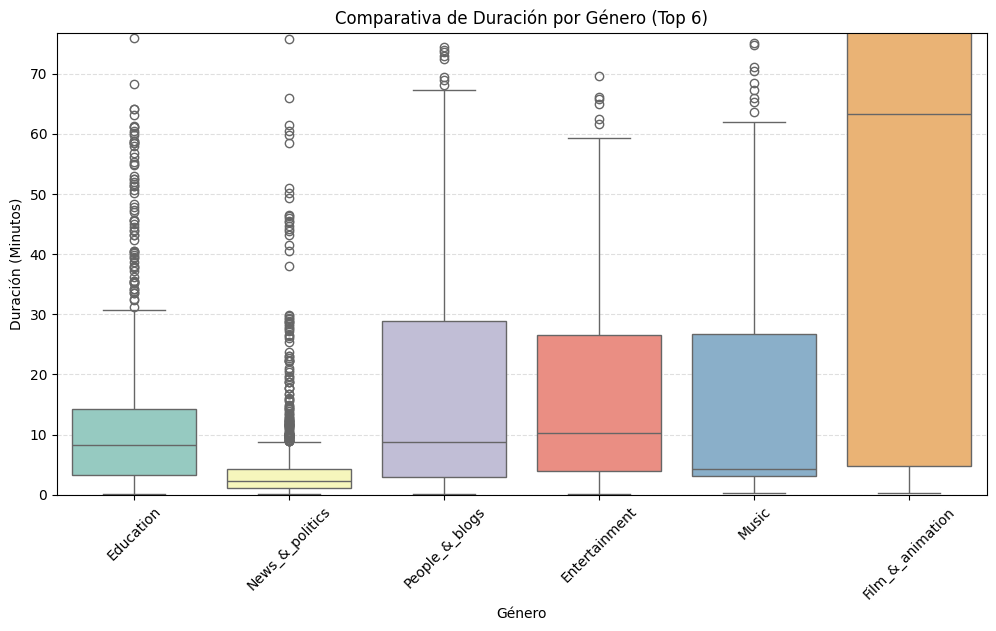

In [19]:

plt.figure(figsize=(12, 6))

# Boxplot
sns.boxplot(x='Genero', y='Duracion', data=df_comparativa_generos, palette='Set3')

# Zoom
limite_superior = df_comparativa_generos['Duracion'].quantile(0.95) * 0.8
plt.ylim(0, limite_superior)

# Detalles
plt.title('Comparativa de Duración por Género (Top 6)')
plt.xlabel('Género')
plt.ylabel('Duración (Minutos)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

Entre los géneros de alta variabilidad tenemos 'Entertainment' y 'Film' presentan las cajas más grandes y bigotes que se extienden notablemente, indicando que no tienen una duración estandarizada y pueden contener desde clips cortos hasta largometrajes. Se confirma la relación Entertainment-Film.

Entre los géneros más compactos están 'Society' y 'Music', que muestran una concentración masiva en duraciones cortas (mediana inferior a 5-10 minutos). En Society, la enorme cantidad de outliers sugiere que, aunque la mayoría son clips breves, existe un volumen constante de vídeos extensos que nuestro modelo va a tener aprender a gestionar.


# Duración (Extra)

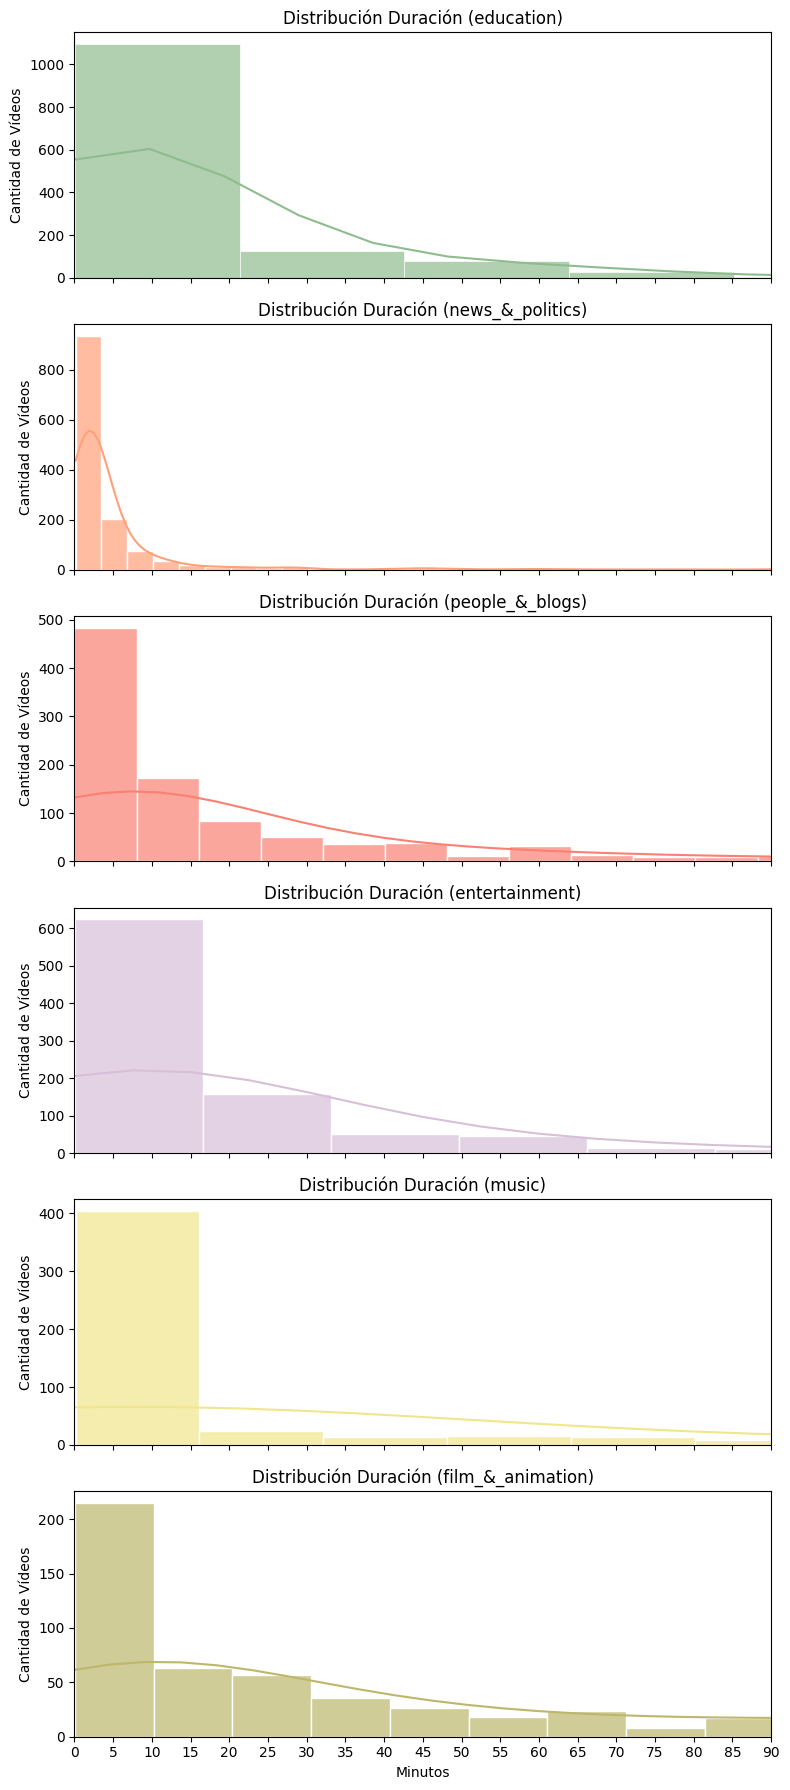

In [20]:

# Configuración
fig, ax = plt.subplots(6, 1, figsize=(8,18), sharex=True)

colores = ['darkseagreen', 'lightsalmon', 'salmon', 'thistle', 'khaki', 'darkkhaki']

for i, nombre, color in zip(range(0, 6), nombres, colores):
    utils.graficar_histograma_duracion(dfs_generos[nombre], f'Distribución Duración ({nombre})', ax[i], color)

plt.tight_layout()
plt.show()